# **NFL Sack Model**
By Andrew Wolfe

# **Import Python Libraries and Merge Datasets**

In [ ]:
import pandas as pd
import pprint
import numpy as np
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, log_loss, brier_score_loss
import statsmodels.api as sm
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

**Loading and Merging Datasets**

In [ ]:
play1 = pd.read_csv('play_by_play_2021.csv')
play2 = pd.read_csv('play_by_play_2022.csv')
play3 = pd.read_csv('play_by_play_2023.csv')

full_play_data = pd.concat([play1, play2, play3], ignore_index=True)

<ipython-input-52-234bf440eaff>:1: DtypeWarning: Columns (179,180,182,183,189,190,193,194,197,198,203,204,205,206,218,219,220,233,234,235,236,237,238,253,254,255,260,262,263,283,284) have mixed types. Specify dtype option on import or set low_memory=False.
  play1 = pd.read_csv('play_by_play_2021.csv')
<ipython-input-52-234bf440eaff>:2: DtypeWarning: Columns (45,179,180,182,183,187,188,189,190,193,194,197,198,203,204,205,206,213,214,218,219,220,222,224,226,243,244,245,248,249,253,254,255,260,262,263,266,267,268,269,283,284) have mixed types. Specify dtype option on import or set low_memory=False.
  play2 = pd.read_csv('play_by_play_2022.csv')
<ipython-input-52-234bf440eaff>:3: DtypeWarning: Columns (45,179,180,182,183,189,190,197,198,203,204,205,206,218,219,220,222,224,226,253,254,255,260,262,263,283,284,332) have mixed types. Specify dtype option on import or set low_memory=False.
  play3 = pd.read_csv('play_by_play_2023.csv')


After merging the play-by-play datasets from 2021-2023, it is now time to explore the data through exploratory data analysis.

# **EDA and Assessing the Data**

In the next couple lines of code, I will be reviewing the first 5 rows of the dataset, looking at the data types, and evaluating the IQR, mean, count, unique items, and standard deviation information within the data.

In [ ]:
full_play_data.head()

,play_id,game_id,old_game_id,home_team,away_team,season_type,week,posteam,posteam_type,defteam,...,out_of_bounds,home_opening_kickoff,qb_epa,xyac_epa,xyac_mean_yardage,xyac_median_yardage,xyac_success,xyac_fd,xpass,pass_oe
0,1,2021_01_ARI_TEN,2021091207,TEN,ARI,REG,1,NaN,NaN,NaN,...,0,1,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,40,2021_01_ARI_TEN,2021091207,TEN,ARI,REG,1,TEN,home,ARI,...,0,1,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,55,2021_01_ARI_TEN,2021091207,TEN,ARI,REG,1,TEN,home,ARI,...,0,1,-1.399805,NaN,NaN,NaN,NaN,NaN,0.491433,-49.143299
3,76,2021_01_ARI_TEN,2021091207,TEN,ARI,REG,1,TEN,home,ARI,...,0,1,0.032412,1.165133,5.803177,4.0,0.896654,0.125098,0.697346,30.265415
4,100,2021_01_ARI_TEN,2021091207,TEN,ARI,REG,1,TEN,home,ARI,...,0,1,-1.532898,0.256036,4.147637,2.0,0.965009,0.965009,0.978253,2.174652


In [ ]:
full_play_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149021 entries, 0 to 149020
Columns: 372 entries, play_id to pass_oe
dtypes: float64(176), int64(39), object(157)
memory usage: 422.9+ MB


In [ ]:
full_play_data.describe()

,play_id,old_game_id,week,yardline_100,quarter_seconds_remaining,half_seconds_remaining,game_seconds_remaining,quarter_end,drive,sp,...,out_of_bounds,home_opening_kickoff,qb_epa,xyac_epa,xyac_mean_yardage,xyac_median_yardage,xyac_success,xyac_fd,xpass,pass_oe
count,149021.000000,1.490210e+05,149021.000000,138456.000000,149012.000000,149012.000000,149012.000000,149021.000000,147324.000000,149021.000000,...,149021.000000,149021.000000,147313.000000,52016.000000,52016.000000,52016.000000,52016.000000,52016.000000,113772.000000,110783.000000
mean,2113.595352,2.022227e+09,9.919716,48.655927,409.662906,805.117635,1703.631848,0.017575,11.484537,0.073365,...,0.087525,0.522618,-0.008791,0.735379,5.498225,3.667602,0.776626,0.577784,0.628293,-1.058609
std,1233.409358,8.540892e+05,5.606124,24.289468,282.778210,561.418127,1060.444788,0.131400,6.657143,0.260736,...,0.282603,0.499490,1.241360,0.538072,2.534353,2.568964,0.252254,0.355003,0.240076,42.325348
min,1.000000,2.021091e+09,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,-13.031218,-3.181688,0.303169,0.000000,0.017248,0.008024,0.015715,-99.512959
25%,1053.000000,2.021122e+09,5.000000,31.000000,145.000000,274.000000,777.000000,0.000000,6.000000,0.000000,...,0.000000,0.000000,-0.561521,0.327403,3.738388,2.000000,0.559248,0.241949,0.457245,-42.475410
50%,2098.000000,2.022111e+09,10.000000,50.000000,390.000000,787.000000,1800.000000,0.000000,11.000000,0.000000,...,0.000000,1.000000,0.000000,0.611368,4.625973,3.000000,0.982598,0.478504,0.599331,4.036379
75%,3148.000000,2.023101e+09,15.000000,70.000000,654.000000,1289.000000,2594.000000,0.000000,17.000000,0.000000,...,0.000000,1.000000,0.509058,1.003755,6.918719,5.000000,1.000000,0.999133,0.856773,33.529690
max,5523.000000,2.024021e+09,22.000000,99.000000,900.000000,1800.000000,3600.000000,1.000000,35.000000,1.000000,...,1.000000,1.000000,8.882384,9.015523,23.904970,30.000000,1.000000,1.000000,0.997580,97.995057


In [ ]:
full_play_data.describe().T

,count,mean,std,min,25%,50%,75%,max
play_id,149021.0,2.113595e+03,1233.409358,1.000000e+00,1.053000e+03,2.098000e+03,3.148000e+03,5.523000e+03
old_game_id,149021.0,2.022227e+09,854089.248138,2.021091e+09,2.021122e+09,2.022111e+09,2.023101e+09,2.024021e+09
week,149021.0,9.919716e+00,5.606124,1.000000e+00,5.000000e+00,1.000000e+01,1.500000e+01,2.200000e+01
yardline_100,138456.0,4.865593e+01,24.289468,1.000000e+00,3.100000e+01,5.000000e+01,7.000000e+01,9.900000e+01
quarter_seconds_remaining,149012.0,4.096629e+02,282.778210,0.000000e+00,1.450000e+02,3.900000e+02,6.540000e+02,9.000000e+02
...,...,...,...,...,...,...,...,...
xyac_median_yardage,52016.0,3.667602e+00,2.568964,0.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00,3.000000e+01
xyac_success,52016.0,7.766255e-01,0.252254,1.724841e-02,5.592482e-01,9.825983e-01,1.000000e+00,1.000000e+00
xyac_fd,52016.0,5.777844e-01,0.355003,8.024425e-03,2.419491e-01,4.785036e-01,9.991331e-01,1.000000e+00
xpass,113772.0,6.282930e-01,0.240076,1.571486e-02,4.572446e-01,5.993312e-01,8.567732e-01,9.975798e-01


**Number of unique items for each column**

In [ ]:
full_play_data.nunique()

,0
play_id,4987
game_id,854
old_game_id,854
home_team,32
away_team,32
...,...
xyac_median_yardage,28
xyac_success,30728
xyac_fd,31526
xpass,112350


Below, I am looking at the number of rows and columns in the dataset. Also, I am inspecting the categorical and numerical features. As seen below, there are a ton of potential features. It will be crucial to properly determine which columns to use in the machine learning model.

In [ ]:
print(f'Total Rows: {full_play_data.shape[0]}')
print(f'Total Columns: {full_play_data.shape[1]}')

Total Rows: 149021
Total Columns: 372


In [ ]:
numerical_features = full_play_data.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_features = full_play_data.select_dtypes(include=['object']).columns.tolist()

count_numerical_features = len(numerical_features)
count_categorical_features = len(categorical_features)
print(f"Number of Numerical Features: {count_numerical_features}")
print(f"Number of Categorical Features: {count_categorical_features}")

Number of Numerical Features: 215
Number of Categorical Features: 157


In [ ]:
print(numerical_features)

['play_id', 'old_game_id', 'week', 'yardline_100', 'quarter_seconds_remaining', 'half_seconds_remaining', 'game_seconds_remaining', 'quarter_end', 'drive', 'sp', 'qtr', 'down', 'goal_to_go', 'ydstogo', 'ydsnet', 'yards_gained', 'shotgun', 'no_huddle', 'qb_dropback', 'qb_kneel', 'qb_spike', 'qb_scramble', 'air_yards', 'yards_after_catch', 'kick_distance', 'home_timeouts_remaining', 'away_timeouts_remaining', 'timeout', 'posteam_timeouts_remaining', 'defteam_timeouts_remaining', 'total_home_score', 'total_away_score', 'posteam_score', 'defteam_score', 'score_differential', 'posteam_score_post', 'defteam_score_post', 'score_differential_post', 'no_score_prob', 'opp_fg_prob', 'opp_safety_prob', 'opp_td_prob', 'fg_prob', 'safety_prob', 'td_prob', 'extra_point_prob', 'two_point_conversion_prob', 'ep', 'epa', 'total_home_epa', 'total_away_epa', 'total_home_rush_epa', 'total_away_rush_epa', 'total_home_pass_epa', 'total_away_pass_epa', 'air_epa', 'yac_epa', 'comp_air_epa', 'comp_yac_epa', 'tot

**Data Reduction - Filtering for Only Pass Plays**

I will filter for only pass plays because this model is predicting whether the next pass play will result in a sack. A 'sack' in football can only occur on plays where the the qb_dropback is equal to 1, emphasizing plays where the quarterback is throwing the football. It is crucial to ensure that the correct data is segmented for this model.

In [ ]:
full_play_data = full_play_data[full_play_data['qb_dropback'] == 1]

**Missing Data in the new dataset of only pass plays**

Now, I want to check and see which columns have missing values in them in the new filtered dataset.

In [ ]:
nan_counts = full_play_data.isna().sum()
print("Missing values in each column:")
print(nan_counts)

Missing values in each column:
play_id                    0
game_id                    0
old_game_id                0
home_team                  0
away_team                  0
                       ...  
xyac_median_yardage    13115
xyac_success           13115
xyac_fd                13115
xpass                    285
pass_oe                  285
Length: 372, dtype: int64


I will calculate the total number of rows and columns in the new filtered dataset that contains only pass plays (qb_dropback is 1).

In [ ]:
print(f'Total Rows: {full_play_data.shape[0]}')
print(f'Total Columns: {full_play_data.shape[1]}')

Total Rows: 65131
Total Columns: 372


**Distribution of our Target Variable 'Sack'**

In [ ]:
full_play_data['sack'].value_counts(normalize=True)

,proportion
sack,
0.0,0.936589
1.0,0.063411


About 6.34% of pass plays resulted in a sack from 2021-2023.

**Snap counts for each QB**

In [ ]:
full_play_data['passer_player_name'].value_counts()

,count
passer_player_name,
P.Mahomes,2374
J.Allen,2060
J.Herbert,1977
T.Lawrence,1942
J.Goff,1893
...,...
S.Clifford,1
D.Achane,1
D.Brown,1


Patrick Mahomes led the NFL in snap count for all QB's from 2021-2023. This makes sense as the Chiefs played in at least the AFC Championship in all three years and in the Super Bowl for two of them as well (no significant injuries too).

**Distribution of the 'down' variable in our dataset**

In [ ]:
full_play_data['down'].value_counts(normalize=True)

,proportion
down,
1.0,0.365929
2.0,0.336705
3.0,0.272646
4.0,0.024720


The down distribution reveals that passing plays were most common on 1st down and least common on 4th down from 2021-2023. Again, this seems logical!

**Quarterbacks that get sacked the Most**

Assessing the imbalance within the sack variable and other important features, such as QBs, offensive teams, and defensive teams. This will give more insight into which factors influence the likelihood of a sack.

In [ ]:
full_play_data[full_play_data['sack'] == 1]['passer_player_name'].value_counts().sort_values(ascending=False)

,count
passer_player_name,
J.Burrow,145
J.Fields,135
R.Wilson,133
B.Mayfield,127
R.Tannehill,113
...,...
D.Dallas,1
T.Hudson,1
L.Woodside,1


Joe Burrow was sacked the most in the NFL from 2021-2023. It would be very interesting in the future to conduct a project determining who is most at fault for this: Joe Burrow, Coaching, or the Bengals Offensive Line?

**Defenses that sack the QB the most**

In [ ]:
full_play_data[full_play_data['sack'] == 1]['defteam'].value_counts().sort_values(ascending=False)

,count
defteam,
KC,164
SF,162
PHI,158
MIA,151
TB,150
BAL,148
BUF,147
PIT,147
DAL,145


The Chiefs defense sacked the opposing quarterback the most during this three year span. Moreover, they did play the most games in this period, so a more accurate metric might be sack rate (percentage of plays that resulted in a sack).

**Teams that allow the most sacks**

In [ ]:
full_play_data[full_play_data['sack'] == 1]['posteam'].value_counts().sort_values(ascending=False)

,count
posteam,
NYG,180
CIN,178
CHI,166
TEN,161
NYJ,159
WAS,156
DEN,155
CAR,153
BAL,145


The New York Giants allowed the most sacks during 2021-2023.

**Distributions of Important Numerical Variables**

It is very important to identify the spread, correlations, and skewness of potentially important features. Understanding the structure of each feature and identifying  outliers is key for determining if any of the variables need to be scaled or transformed before being used in the model. The variables chosen below (after the correlation matrix) are a subset of the numerical features that emphasize game context and team performance. This smaller selection will reduce dimensionality and increase interpretability.

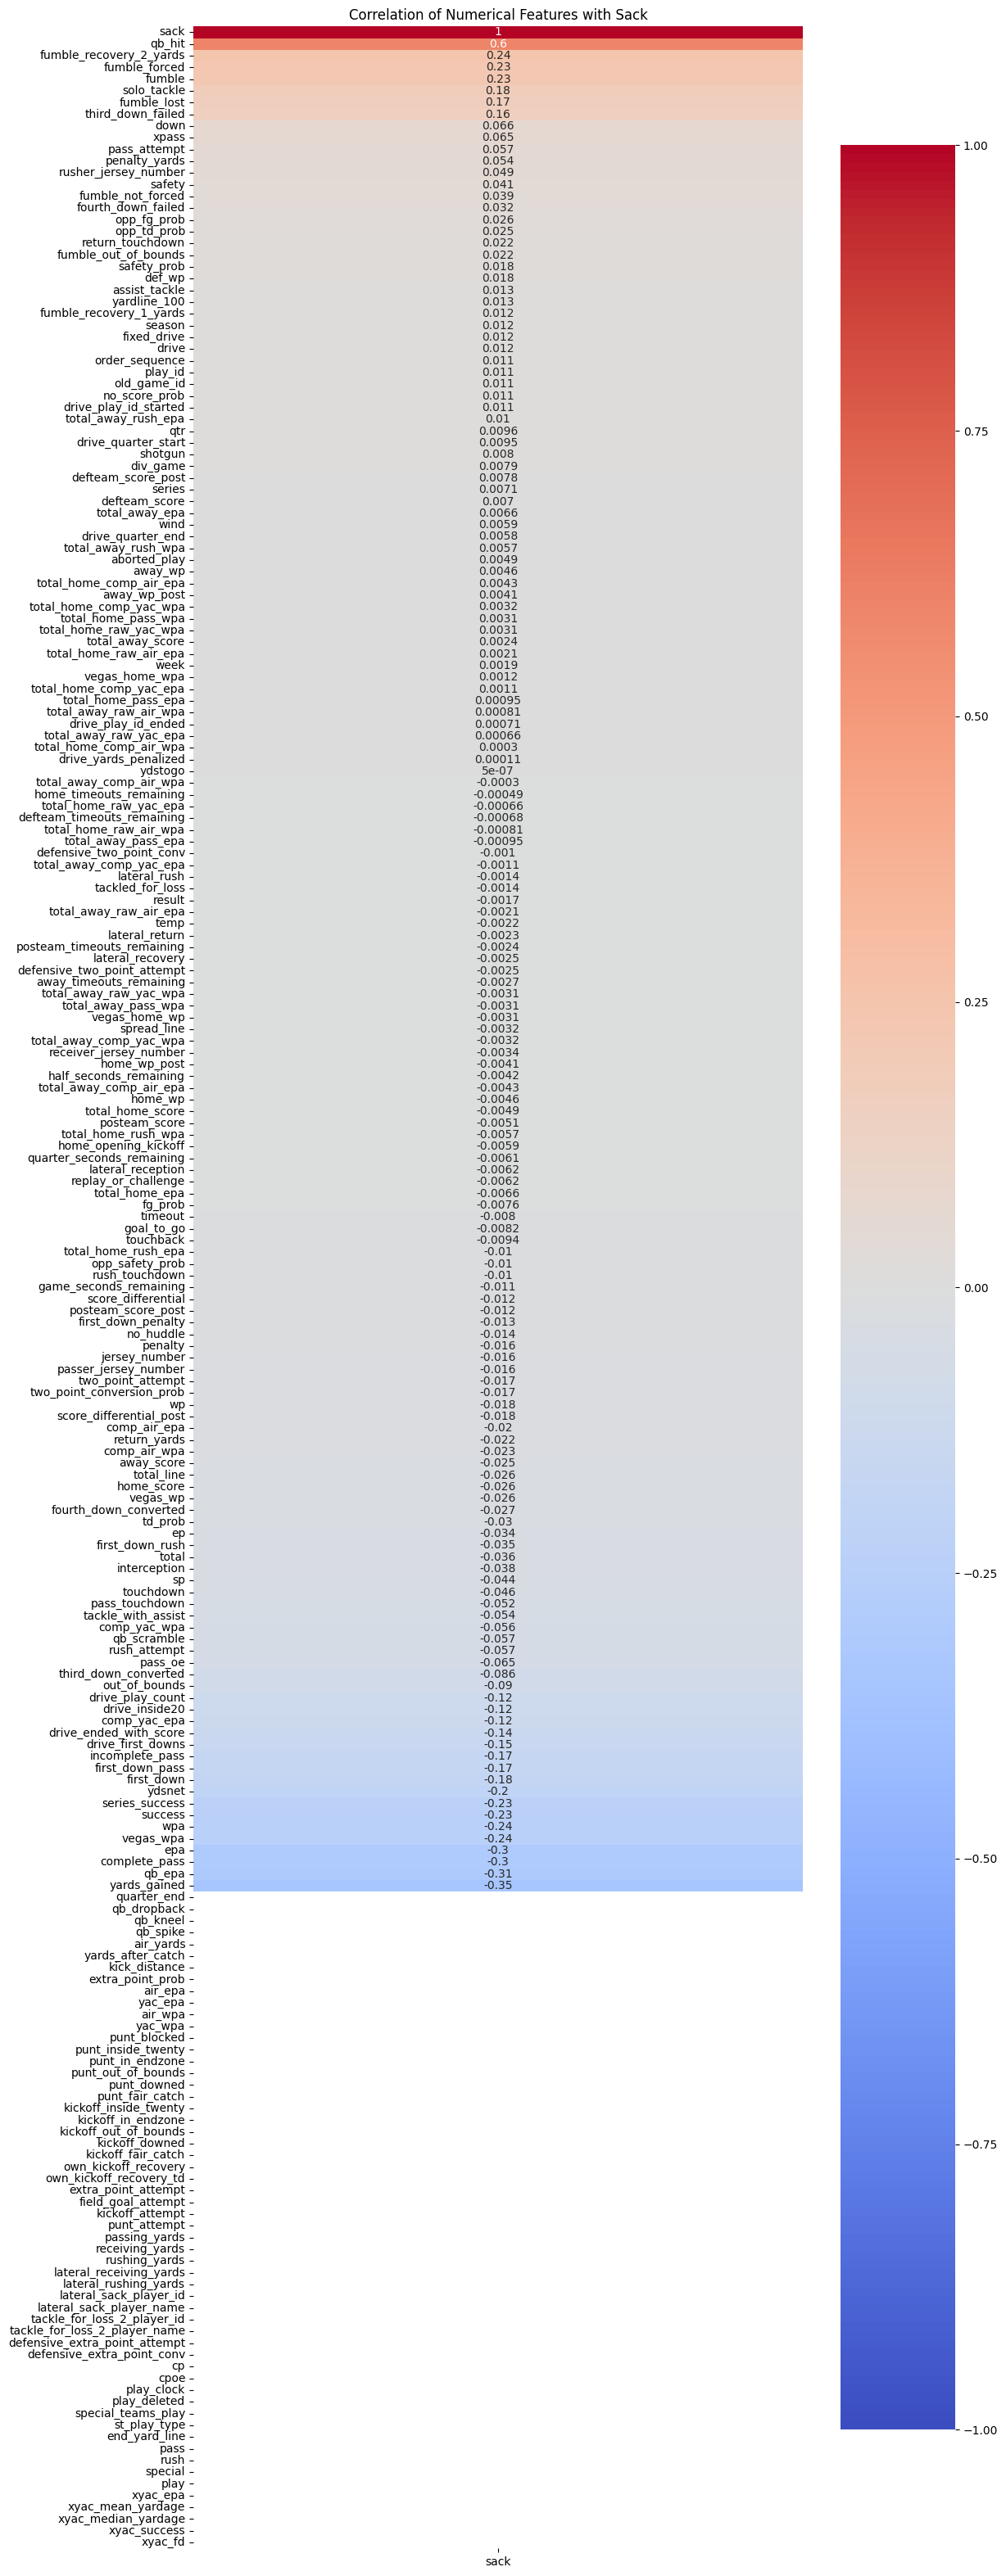

In [ ]:
corr_matrix = full_play_data[numerical_features].corr()

plt.figure(figsize=(12, 40))
sns.heatmap(corr_matrix[['sack']].sort_values(by='sack', ascending=False), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of Numerical Features with Sack')
plt.show()
#No values showing up for some of these features since they are not present usually in passing info

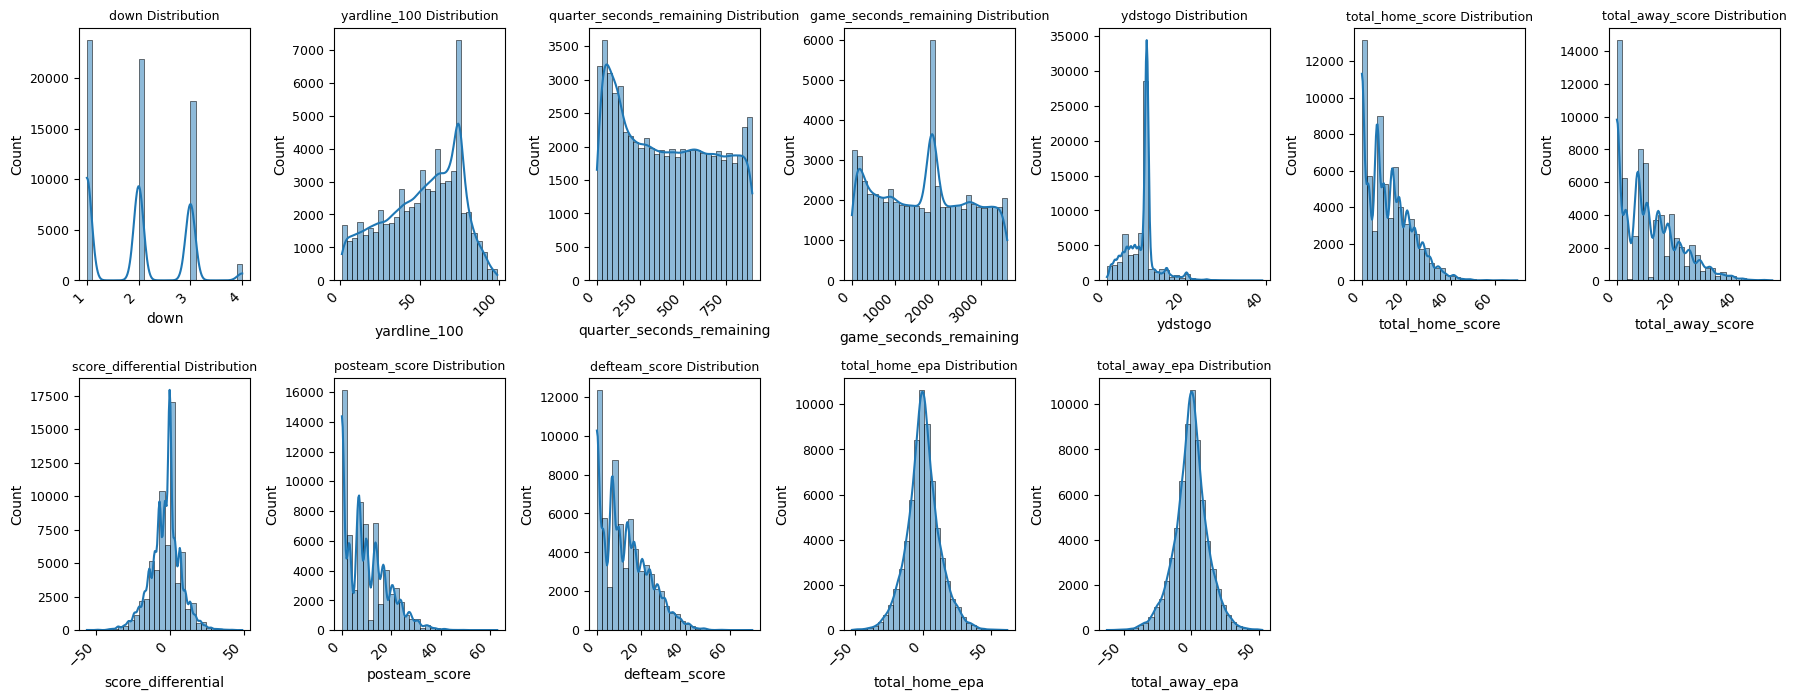

In [ ]:
numerical_features = ['down','yardline_100', 'quarter_seconds_remaining', 'game_seconds_remaining',
                      'ydstogo', 'total_home_score',
                      'total_away_score', 'score_differential', 'posteam_score', 'defteam_score', 'total_home_epa',
                      'total_away_epa']
plt.figure(figsize=(18, 10))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(3, 7, i)
    sns.histplot(full_play_data[feature], kde=True, bins=30)
    plt.title(f'{feature} Distribution', fontsize=9)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

**Boxplots of important numerical features against the target variable 'sack'**

The distribution of the variables 'yardline_100', 'score_differential', 'ydstogo', and 'quarter_seconds_remaining'/'game_seconds_remaining' are extremely intriguing as they appear to show some kind of change depending on if the play resulted in a sack or not. Although these differences may appear small, they are extremel critical in determining what features to use in the model.

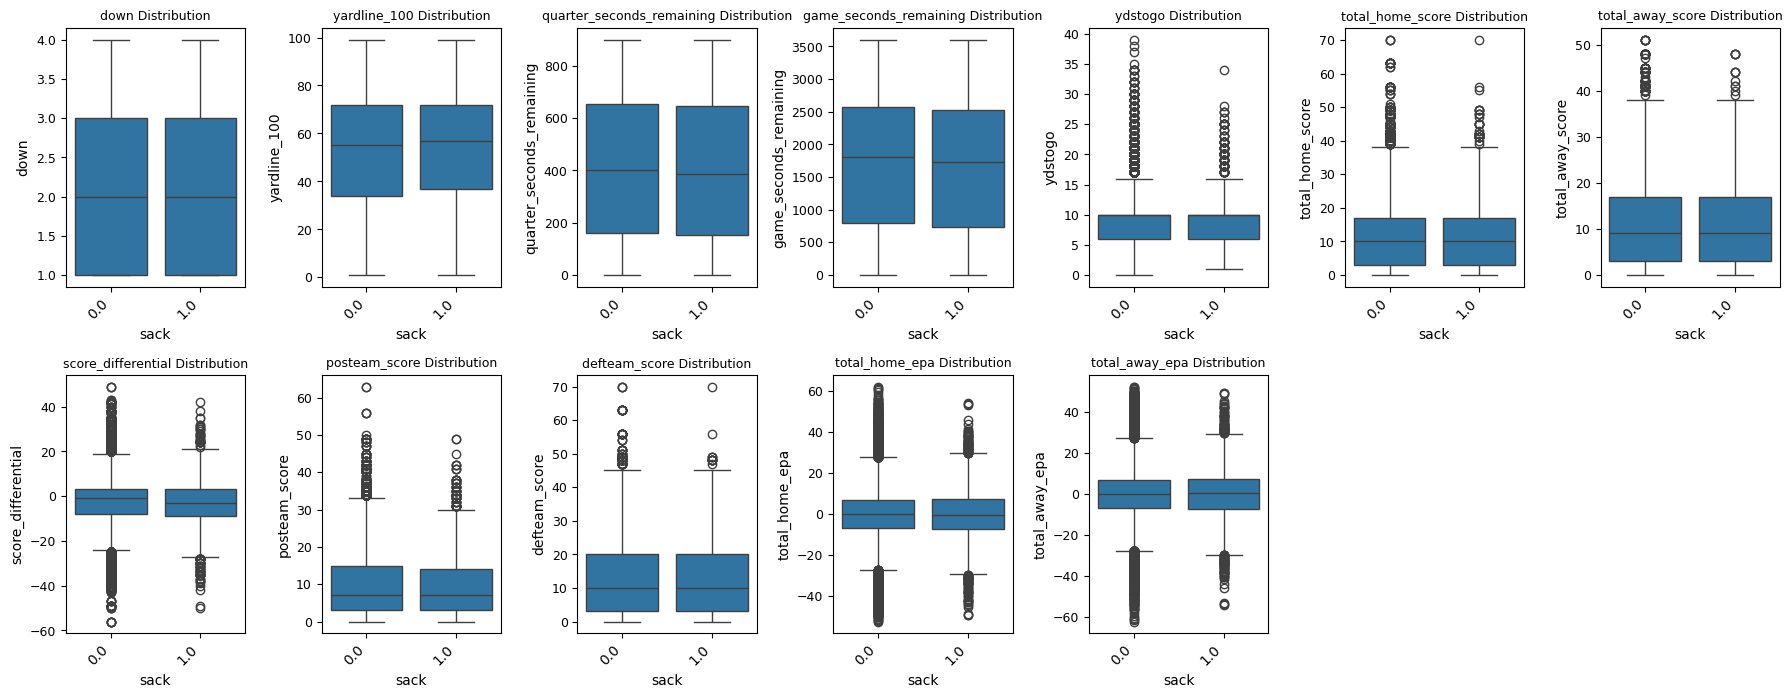

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(18, 10))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(3, 7, i)
    sns.boxplot(data=full_play_data, x='sack', y=feature)
    plt.title(f'{feature} Distribution', fontsize=9)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()

# **Handling Missing Data**

I have identified the important variables in the dataset that seem the most relevant for predicting whether the next pass play will result in a sack. Now that this is done, I must check for missing data and decide what I am going to do with it.

Because there are only about 291 rows of missing data (0.4% of our passing plays dataset row count), it seems that simply just dropping these rows is the best way to deal with them.

In [ ]:
important_variables = ['passer_id', 'down', 'yardline_100', 'ydstogo', 'score_differential']

count_NA = full_play_data[important_variables].isna().sum()
print("Missing values in each column:")
print(count_NA)

Missing values in each column:
passer_id               6
down                  285
yardline_100            0
ydstogo                 0
score_differential      0
dtype: int64


In [ ]:
full_play_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 65131 entries, 3 to 149019
Columns: 372 entries, play_id to pass_oe
dtypes: float64(176), int64(39), object(157)
memory usage: 185.3+ MB


In [ ]:
full_play_data = full_play_data.dropna(subset=['passer_id', 'down'])

In [ ]:
full_play_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 64840 entries, 3 to 149019
Columns: 372 entries, play_id to pass_oe
dtypes: float64(176), int64(39), object(157)
memory usage: 184.5+ MB


As seen above, about 291 rows were dropped from the dataset.

# **Feature Engineering**

Below, I am creating the following two metrics for each QB and defense:

    - **career_sack_rate_qb_prev:** Entire career sack rate leading up that current play for the respective QB.
    - **rolling_sack_rate_qb_prev:** Short-term sack rate calculated based on the previous 8 weeks for the respective QB.

    - **sack_rate_def_prev**: Overall sack rate leading up that current play for the respective defense.
    - **rolling_sack_rate_def_prev** Short-term sack rate calculated based on the previous 8 weeks for the respective defense.


These four variables will play a large factor in creating the model. They are extremely important for helping identify and evaluate how efficient the defense has been at sacking the opposing QB and at the same time, how efficient each QB has been at avoiding sacks in both the short and long run. Creating these important features provides context for each sack, both in the past and present.

Also, notice that by using using the column 'passer_id' and shifted versions of the sack rates (for QB and defense), data leakage is prevented. Data leakage refers to the model having access to information or features when training the data but not at prediction time. In this case, 'passer_id' is used instead of 'passer_player_name' as it is a constant identifier. Because of this, it is much safer to use 'passer_id' than 'passer_player_name.'

**Cumulative Rolling Sack Rate Over the Last 8 Weeks for Qbs and Defense**

**QB**

In [ ]:
full_play_data = full_play_data.sort_values(by=['passer_id', 'season', 'week']).reset_index(drop=True)

full_play_data['cum_sacks_qb'] = full_play_data.groupby('passer_id')['sack'].cumsum()
full_play_data['cum_attempts_qb'] = full_play_data.groupby('passer_id')['qb_dropback'].cumcount() + 1
full_play_data['career_sack_rate_qb'] = full_play_data['cum_sacks_qb'] / full_play_data['cum_attempts_qb']
full_play_data['career_sack_rate_qb_prev'] = full_play_data.groupby('passer_id')['career_sack_rate_qb'].shift(1)

full_play_data['rolling_sacks_qb'] = full_play_data.groupby('passer_id')['sack'] \
    .rolling(window=8, min_periods=1).sum().reset_index(level=0, drop=True)

full_play_data['rolling_attempts_qb'] = full_play_data.groupby('passer_id')['qb_dropback'] \
    .rolling(window=8, min_periods=1).count().reset_index(level=0, drop=True)

full_play_data['rolling_sack_rate_qb'] = full_play_data['rolling_sacks_qb'] / full_play_data['rolling_attempts_qb']

full_play_data['rolling_sack_rate_qb_prev'] = full_play_data.groupby('passer_id')['rolling_sack_rate_qb'].shift(1)


**Defense**

In [ ]:
full_play_data = full_play_data.sort_values(by=['defteam', 'season', 'week']).reset_index(drop=True)

full_play_data['cum_sacks_def'] = full_play_data.groupby('defteam')['sack'].cumsum()
full_play_data['cum_attempts_def'] = full_play_data.groupby('defteam')['qb_dropback'].cumcount() + 1
full_play_data['sack_rate_def'] = full_play_data['cum_sacks_def'] / full_play_data['cum_attempts_def']
full_play_data['sack_rate_def_prev'] = full_play_data.groupby('defteam')['sack_rate_def'].shift(1)

full_play_data['rolling_sacks_def'] = full_play_data.groupby('defteam')['sack'] \
    .rolling(window=8, min_periods=1).sum().reset_index(level=0, drop=True)

full_play_data['rolling_attempts_def'] = full_play_data.groupby('defteam')['qb_dropback'] \
    .rolling(window=8, min_periods=1).count().reset_index(level=0, drop=True)

full_play_data['rolling_sack_rate_def'] = full_play_data['rolling_sacks_def'] / full_play_data['rolling_attempts_def']

full_play_data['rolling_sack_rate_def_prev'] = full_play_data.groupby('defteam')['rolling_sack_rate_def'].shift(1)

**NA Check for the new columns**

In [ ]:
important_variables = ['passer_id', 'down', 'yardline_100', 'ydstogo', 'score_differential','career_sack_rate_qb_prev','rolling_sack_rate_qb_prev','sack_rate_def_prev','rolling_sack_rate_def_prev']

count_NA = full_play_data[important_variables].isna().sum()
print("Missing values in each column:")
print(count_NA)

Missing values in each column:
passer_id                       0
down                            0
yardline_100                    0
ydstogo                         0
score_differential              0
career_sack_rate_qb_prev      198
rolling_sack_rate_qb_prev     198
sack_rate_def_prev             32
rolling_sack_rate_def_prev     32
dtype: int64


As seen above, there are a few NAs in the new columns and features created. To correct this and make the features available for the model, the missing values are filled with their respective column averages. This way, outliers and bias are eliminated as the mean provides a neutral, data-driven estimate representing the overall distribution where prior data did not exist.

In [ ]:
full_play_data['career_sack_rate_qb_prev'].fillna(full_play_data['career_sack_rate_qb_prev'].mean(), inplace=True)
full_play_data['rolling_sack_rate_qb_prev'].fillna(full_play_data['rolling_sack_rate_qb_prev'].mean(), inplace=True)
full_play_data['sack_rate_def_prev'].fillna(full_play_data['sack_rate_def_prev'].mean(), inplace=True)
full_play_data['rolling_sack_rate_def_prev'].fillna(full_play_data['rolling_sack_rate_def_prev'].mean(), inplace=True)

<ipython-input-80-76e4fd8b458a>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  full_play_data['career_sack_rate_qb_prev'].fillna(full_play_data['career_sack_rate_qb_prev'].mean(), inplace=True)
<ipython-input-80-76e4fd8b458a>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

**Correlation Chart With Important Numerical Features**

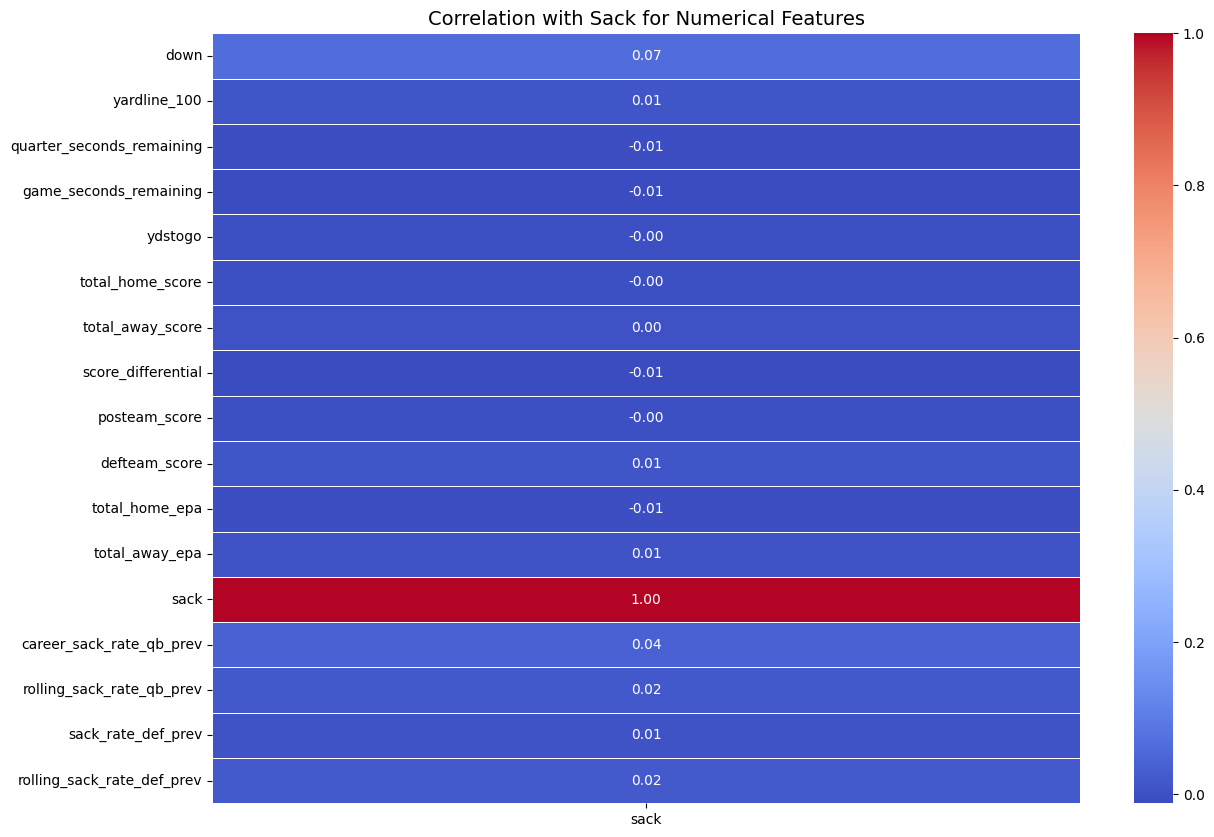

In [ ]:
corr_matrix = full_play_data[numerical_features + ['sack']+['career_sack_rate_qb_prev']+['rolling_sack_rate_qb_prev']+['sack_rate_def_prev']+['rolling_sack_rate_def_prev']].corr()
corr_with_sack = corr_matrix[['sack']]

plt.figure(figsize=(14, 10))
sns.heatmap(corr_with_sack, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation with Sack for Numerical Features', fontsize=14)
plt.show()

The correlation analysis above gives us small insight into comprehending the linear relationship between 'sack' and other potential feature variables. This is crucial for identifying what features  should be used in the model.

By using the information above, it appears that the following variables will be most useful for predicting whether the next pass play will result in a 'sack':  **'down', 'yardline_100', 'ydstogo', 'score_differential', 'career_sack_rate_qb_prev', 'rolling_sack_rate_qb_prev', 'sack_rate_def_prev',  'rolling_sack_rate_def_prev',** and  **'game_seconds_remaining'**.

# **Model Building**

To begin the model building of the project, I will select the key features I identified above and create a training and testing dataset. The purpose of the training set is for the model to begin learning patterns and relationships that exist. The testing dataset is then used to evaluate the performance of the model (unseen data). This is crucial to ensure accuracy and reduce over-fitting.



**Creating the Train and Test Datasets**

In [ ]:
important_variables = ['down', 'yardline_100', 'ydstogo', 'score_differential',
                       'career_sack_rate_qb_prev', 'rolling_sack_rate_qb_prev', 'sack_rate_def_prev','rolling_sack_rate_def_prev',
                       'game_seconds_remaining']

X = full_play_data[important_variables]
y = full_play_data['sack']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

The following models will be tested:

**Logistic Regression** - This model predicts the likelihood of a sack as a function of a linear combination of the input variables. It is most effective when there is a linear relationship between the feature-outcome relationship and is primarily used for binary classification (yes/no) - predicting which outcome is most likely.

**Gradient Boosting**  - This ensemble technique typically uses decision trees to build strong predictive models. The decision trees are built in a series in which each subsequent trees corrects the errors of the previous one. The collection of weak models are built into a single accurate model.

**Random Forest** - A Random Forest Model uses the combination of multiple decision trees to make a well-rounded prediction. It uses ensemble learning (combination of models to produce efficient results) to get to a single result and is very flexible.  

**Naive Bayes** - This model is based on Bayes' Theorem and all features are assumed as independent. Although the independence assumption may reduce the accuracy of the model, it makes it suitable for basic classification tasks and is tested as a probabilistic model.

**Support Vector Machines** - The SVM model will attempt to find the differentiator between sacks and non-sacks using maximum class margin. It can be very slow when working with a large dataset but is capable operating on non-linear relationships.

**Logistic Regression**

In [ ]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)
y_pred_proba_log = log_reg.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f'AUC: {roc_auc_score(y_test, y_pred_proba_log)}')
print(f'Log Loss: {log_loss(y_test, y_pred_proba_log)}')
print(f'Brier Score: {brier_score_loss(y_test, y_pred_proba_log)}')

log_metrics = {
    'Model': 'Logistic Regression',
    'AUC': roc_auc_score(y_test, y_pred_proba_log),
    'Log Loss': log_loss(y_test, y_pred_proba_log),
    'Brier Score': brier_score_loss(y_test, y_pred_proba_log)
}

              precision    recall  f1-score   support

         0.0       0.94      1.00      0.97     18227
         1.0       0.00      0.00      0.00      1225

    accuracy                           0.94     19452
   macro avg       0.47      0.50      0.48     19452
weighted avg       0.88      0.94      0.91     19452

AUC: 0.5882851522130771
Log Loss: 0.2323308101006076
Brier Score: 0.05868074128273282


**Gradient Boosting**

In [ ]:
grad_boost = XGBClassifier()
grad_boost.fit(X_train, y_train)
y_pred = grad_boost.predict(X_test)
y_pred_proba_gb = grad_boost.predict_proba(X_test)[:, 1]


print(classification_report(y_test, y_pred))
print(f'AUC: {roc_auc_score(y_test, y_pred_proba_gb)}')
print(f'Log Loss: {log_loss(y_test, y_pred_proba_gb)}')
print(f'Brier Score: {brier_score_loss(y_test, y_pred_proba_gb)}')

grad_boost_metrics = {
    'Model': 'Gradient Boosting',
    'AUC': roc_auc_score(y_test, y_pred_proba_gb),
    'Log Loss': log_loss(y_test, y_pred_proba_gb),
    'Brier Score': brier_score_loss(y_test, y_pred_proba_gb)
}

              precision    recall  f1-score   support

         0.0       0.94      1.00      0.97     18227
         1.0       0.17      0.00      0.00      1225

    accuracy                           0.94     19452
   macro avg       0.55      0.50      0.49     19452
weighted avg       0.89      0.94      0.91     19452

AUC: 0.5630956766313262
Log Loss: 0.2449666006190335
Brier Score: 0.060389585748029155


**Random Forest**

In [ ]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f'AUC: {roc_auc_score(y_test, y_pred_proba_rf)}')
print(f'Log Loss: {log_loss(y_test, y_pred_proba_rf)}')
print(f'Brier Score: {brier_score_loss(y_test, y_pred_proba_rf)}')

rf_metrics = {
    'Model': 'Random Forest',
    'AUC': roc_auc_score(y_test, y_pred_proba_rf),
    'Log Loss': log_loss(y_test, y_pred_proba_rf),
    'Brier Score': brier_score_loss(y_test, y_pred_proba_rf)
}

              precision    recall  f1-score   support

         0.0       0.94      1.00      0.97     18227
         1.0       0.00      0.00      0.00      1225

    accuracy                           0.94     19452
   macro avg       0.47      0.50      0.48     19452
weighted avg       0.88      0.94      0.91     19452

AUC: 0.5757897176536715
Log Loss: 0.2726814788869363
Brier Score: 0.06075431832202344


**Naive Bayes**

In [ ]:
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)
y_pred_proba_nb = nb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f'AUC: {roc_auc_score(y_test, y_pred_proba_nb)}')
print(f'Log Loss: {log_loss(y_test, y_pred_proba_nb)}')
print(f'Brier Score: {brier_score_loss(y_test, y_pred_proba_nb)}')

nb_metrics = {
    'Model': 'Naive Bayes',
    'AUC': roc_auc_score(y_test, y_pred_proba_nb),
    'Log Loss': log_loss(y_test, y_pred_proba_nb),
    'Brier Score': brier_score_loss(y_test, y_pred_proba_nb)
}

              precision    recall  f1-score   support

         0.0       0.94      1.00      0.97     18227
         1.0       0.11      0.00      0.00      1225

    accuracy                           0.94     19452
   macro avg       0.52      0.50      0.48     19452
weighted avg       0.89      0.94      0.91     19452

AUC: 0.583699669586384
Log Loss: 0.23415866276352224
Brier Score: 0.059071095022557044


**Support Vector Machine**

In [ ]:
svm = SVC(probability=True)
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)
y_pred_proba_svm = svm.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f'AUC: {roc_auc_score(y_test, y_pred_proba_svm)}')
print(f'Log Loss: {log_loss(y_test, y_pred_proba_svm)}')
print(f'Brier Score: {brier_score_loss(y_test, y_pred_proba_svm)}')

svm_metrics = {
    'Model': 'Support Vector Machine',
     'AUC': roc_auc_score(y_test, y_pred_proba_svm),
    'Log Loss': log_loss(y_test, y_pred_proba_svm),
    'Brier Score': brier_score_loss(y_test, y_pred_proba_svm)
}

              precision    recall  f1-score   support

         0.0       0.94      1.00      0.97     18227
         1.0       0.00      0.00      0.00      1225

    accuracy                           0.94     19452
   macro avg       0.47      0.50      0.48     19452
weighted avg       0.88      0.94      0.91     19452

AUC: 0.5026081290035079
Log Loss: 0.23514684847284045
Brier Score: 0.05901810265434023


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Plotting Model Metrics**

In [ ]:
metrics_dataframe = pd.DataFrame([log_metrics, grad_boost_metrics, rf_metrics, nb_metrics, svm_metrics])
metrics_dataframe

,Model,AUC,Log Loss,Brier Score
0,Logistic Regression,0.588285,0.232331,0.058681
1,Gradient Boosting,0.563096,0.244967,0.060390
2,Random Forest,0.575790,0.272681,0.060754
3,Naive Bayes,0.583700,0.234159,0.059071
4,Support Vector Machine,0.502608,0.235147,0.059018


# **Evaluation Metrics Explained**

**AUC -** This stands for Area Under the Curve. It is used to assess the performance of a binary classification model (in this case whether the next pass play is a sack (1) or not (0)). These values range from 0.5 to 1, with scores closer to 0.5 suggesting that the model is not better than guessing randomly and scores closer to 1.0 suggesting the model can effectively distinguish between the different class (sack) labels. If the dataset being used is roughly balanced and the target variable a not a zero-inflated event, this is then a great evaluation tool.

**Log Loss -**  This measures the difference between predicted probabilities and actual values. It is common for binary classification models as well and a lower Log Loss score suggest better model performance. Wrong probability predictions are penalized. The lower the Log Loss, the better the model is!

**Brier Score -** The Brier score represents the mean-squared differences between the predicted probability and their corresponding event outcomes (0 or 1). It is great for assessing the accuracy of binary outcomes. The lower the Brier Score, the better the model is!

**ROC Curve**

The ROC Curve (Receiver Operating Characteristic) is a graph of the True Positive Rate, or sensitivity, against the False Positive Rate. It is extremely important for evaluating the overall performance of each model and comparing the diagnostic accuracy. Moreover, the ROC Curve is not optimal for zero-inflated events because of its sensitivity to class imbalance and of likely over-representation of the true negatives (by predicting the negative class every time, the model could achieve a very good ROC AUC score). In the perfect word, the lines of the ROC Curve would occupy the top left corner, emphasizing a very high true positive rate and low false positive rate.

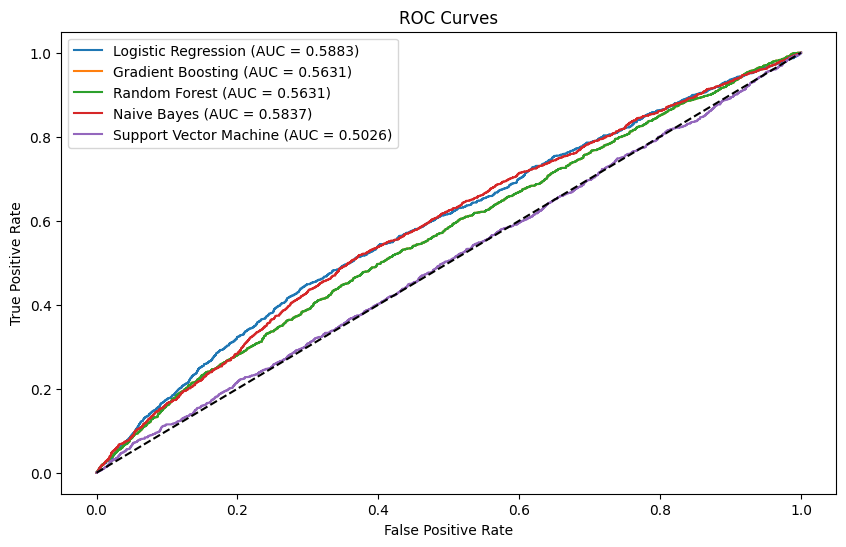

In [ ]:
#Logistic
lg_fpr, lg_tpr, _ = roc_curve(y_test, log_reg.predict_proba(X_test)[:, 1])
lg_auc = auc(lg_fpr, lg_tpr)

#Gradient Boosting
gb_fpr, gb_tpr, _ = roc_curve(y_test, grad_boost.predict_proba(X_test)[:, 1])
gb_auc = auc(gb_fpr, gb_tpr)

#Random Forest
rf_fpr, rf_tpr, _ = roc_curve(y_test, grad_boost.predict_proba(X_test)[:, 1])
rf_auc = auc(rf_fpr, rf_tpr)

#Naive Bayes
nb_fpr, nb_tpr, _ = roc_curve(y_test, nb.predict_proba(X_test)[:, 1])
nb_auc = auc(nb_fpr, nb_tpr)

#SVM
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm.predict_proba(X_test)[:, 1])
svm_auc = auc(svm_fpr, svm_tpr)

plt.figure(figsize=(10, 6))
plt.plot(lg_fpr, lg_tpr, label=f'Logistic Regression (AUC = {lg_auc:.4f})')
plt.plot(gb_fpr, gb_tpr, label=f'Gradient Boosting (AUC = {gb_auc:.4f})')
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.4f})')
plt.plot(nb_fpr, nb_tpr, label=f'Naive Bayes (AUC = {nb_auc:.4f})')
plt.plot(svm_fpr, svm_tpr, label=f'Support Vector Machine (AUC = {svm_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

**AUC Evaluation Tool - Not Ideal for Zero-Inflated Events**

This line chart re-emphasizes that the AUC evaluation tool is not ideal for zero-inflated events, such as predicting sacks in this case. Because of this, it makes sense to evaluate the Log-loss of each model and see how the model's predictabilities align with the average sack rate for all plays.  

**Bins for Predicted Probabilities - Logisitic Regression (Best Performing Model in Terms of Log-Loss)**

In [ ]:
bins = np.arange(0,1.01,0.01)
labels_bins = bins[:-1] + 0.005

binning = pd.cut(y_pred_proba_log, bins=bins)
df_predictions = pd.DataFrame({'predicted_probability': y_pred_proba_log,'actual': y_test})
df_predictions_summary = df_predictions.groupby(binning)['actual'].agg(['count', 'mean'])
df_predictions_summary['binning_mid_point'] = labels_bins

df_predictions_summary = df_predictions_summary[df_predictions_summary['count']>40]
df_predictions_summary

<ipython-input-90-7d4d71ab245d>:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_predictions_summary = df_predictions.groupby(binning)['actual'].agg(['count', 'mean'])


,count,mean,binning_mid_point
"(0.03, 0.04]",525,0.049524,0.035
"(0.04, 0.05]",4812,0.044680,0.045
"(0.05, 0.06]",4130,0.053753,0.055
"(0.06, 0.07]",3490,0.054441,0.065
"(0.07, 0.08]",2609,0.073208,0.075
"(0.08, 0.09]",2134,0.090440,0.085
"(0.09, 0.1]",974,0.104723,0.095
"(0.1, 0.11]",420,0.123810,0.105
"(0.11, 0.12]",163,0.061350,0.115
"(0.12, 0.13]",96,0.093750,0.125


Because the logistic regression performed the best in terms of Log Loss, this is the model I will be using for further analysis of my modeling.

Above, the predicted probabilities from the logistic regression model are divided into bins that have a width of 0.01. Each binned point on this graph shows how many plays fell into that probability range and at the same time, what proportion of them were actually sacks. The model is well-calibrated as the actual sack rate increases when the predicted probabilities increase, confirming that the logistic regression is assessing sack risk well. This can also be shown in the plot below.

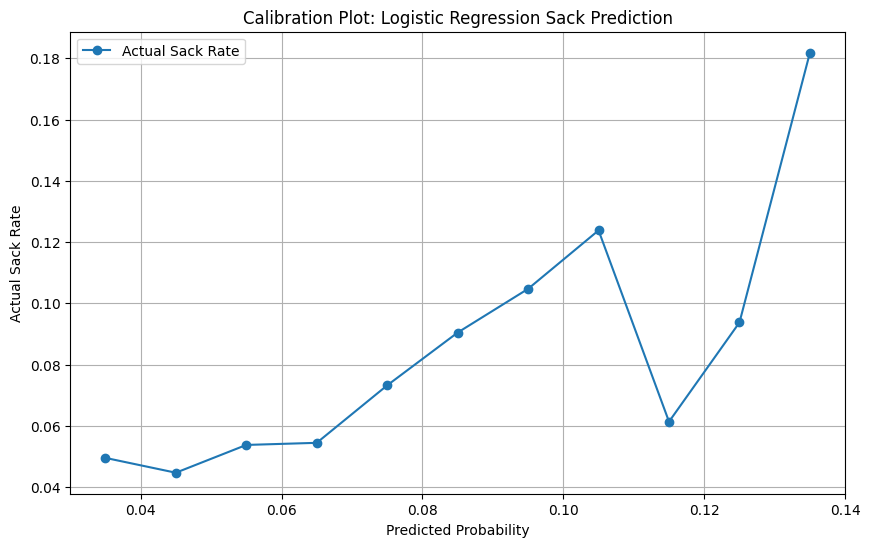

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(df_predictions_summary['binning_mid_point'], df_predictions_summary['mean'], label='Actual Sack Rate', marker='o')
plt.xlabel('Predicted Probability')
plt.ylabel('Actual Sack Rate')
plt.title('Calibration Plot: Logistic Regression Sack Prediction')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
baseline_prob = y_test.mean()
baseline_log_loss = log_loss(y_test, np.full_like(y_test, baseline_prob, dtype=np.float64))
print(f'Baseline Log Loss: {baseline_log_loss:.4f}')

print(f'Logistic Regression Log Loss: {log_loss(y_test, y_pred_proba_log)}')

improvement = (baseline_log_loss - log_loss(y_test, y_pred_proba_log)) / baseline_log_loss * 100

print(f"Improvement in Log Loss: {improvement:.2f}%")

Baseline Log Loss: 0.2351
Logistic Regression Log Loss: 0.2323308101006076
Improvement in Log Loss: 1.17%


To assess the calibration of the logistic regression model for determining whether the next pass play will result in a sack, I grouped predictions into bins using a width of 0.01. The purpose of this was to evaluate how the predicted probabilities from the logistic regression model compare to the actual sack rate for the predictions that fall into this probability range. For instance, if this model projected about a 5% chance of the next pass play resulting in a sack, the expectation would be that 5% of the observed probabilities in this bin would result in a sack. To help with visualization and adjust for sample size, I omitted bins with less than 40 plays.

The baseline log loss of 0.2351 is defined as the error if we just predicted the average probability for every observation.  


The Logistic Regression log loss of 0.2323 reveals how much better this model is at predicting the outcome of a sack on a pass play than the baseline. In this circumstance, a log loss score closer to 0 indicates a better performing model. The 1.17% improvement in log loss when using the Logistic Regression Model compared to the baseline model (simply predicting the average outcome for each observation) further emphasizes this models' success. Please note that the low percent improvement proves how hard it is to predict a sack on any given pass play!

# **Model Chosen**

In conclusion, the best performing model was Logistic Regression. It had the lowest Log Loss score among all of the models tested. Because of its ability to predict probabilities closely aligned with the outcome of the next play being a sack or not, the Logistic Regression performed the best. This model does a great job establishing a solid foundation of practicality and reliability.

**Feature Important Plot - Logistic Regression**

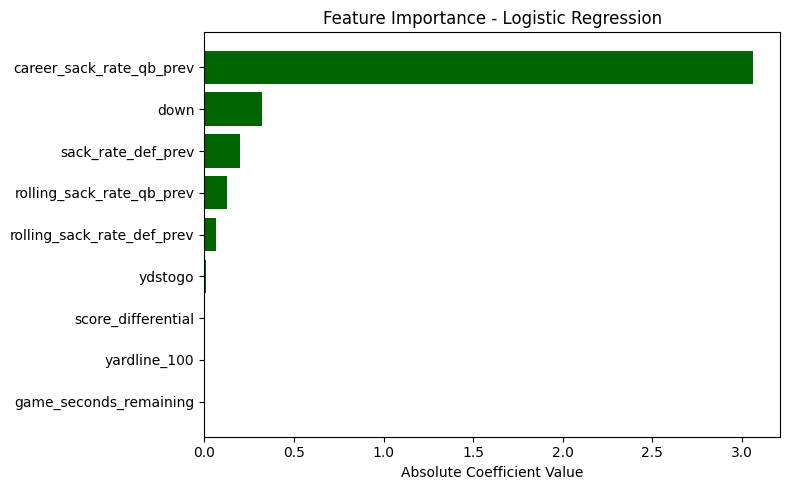

In [ ]:
coefs = log_reg.coef_[0]
importance_df = pd.DataFrame({
    'Feature': important_variables,
    'Coefficient': coefs,
    'Abs_Coefficient': np.abs(coefs)
}).sort_values(by='Abs_Coefficient', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'], importance_df['Abs_Coefficient'], color='darkgreen')
plt.xlabel('Absolute Coefficient Value')
plt.title('Feature Importance - Logistic Regression')
plt.tight_layout()
plt.show()

Creating an feature important chart of the Logistic Regression model helps identify the most important features in the model. The chart reveals that 'career_sack_rate_qb_prev', 'down', and 'sack_rate_def_prev' are the most important variables. Taking into effect the defenses and QB's past statistics of sacking a quarterback or being sacked has a large impact for predicting if the next passing play will result in a sack!

# **Next Steps and Conclusion**

Although the model performed fairly well with the performance evaluation metrics, there are always ways to improve the model going forward. Fine-tunning hyperparameters and optimizing model settings will continue to help produce the most effective model. Another way to improve the model is to improve and enrich the model features. Adding a column emphasizing offensive or defensive line strength, blitz tendencies, weather, or even how much defensive pressure there was on a given play would all continue to boost model performance and at the same time, potray the complexity of an NFL play extremely well. Moreover, looking into different types of models is always a possibility. Whether it be through ensemble blending (i.e. blending Logistic Regression with Gradient Boosting), calibration (calibration classifier to combine tree power), or even time aware and temporal dependencies models, it is always informative to observe the performance of these techniques.

Developing a repeatable process through iteration and data pipelines is another potential area to look into in the future. It would be extremely useful for the model to be updated weekly with lots of new data. Additionally, automated data refreshes will be extremely important to monitor so that the models can be automatically updated and most up-to-date. Through AWS Lambda or even Airflow, one could also use batch processing to automate these predictions and data refreshes. Moreover, monitoring each of the key features to ensure they do not drift or change over time is significant. If this were to happen, the models  would change significanlty as there would be more differences in the distributions of the data than when the models were initially created.

Lastly, model deployment will be extremely critical. It can be through an API, such as Flask or FastAPI, or even a dashboard. Interactivity, such as allowing coaches or fans to input game context for certain plays to explore sack probabilities, will be crucial for the model to make a real impact. Making the model accessible and user-friendly to coaches, fans, and bettors is significant going forward!

In conclusion, the Logistic Regression model was chosen to predict the probability for whether the next passing play will result in a sack. It performed well across evaluation metrics, including Log Loss, indicating well-calibrated probability metrics. The model used the following features to help predict our target variable 'sack': 'down', 'yardline_100', 'ydstogo', 'score_differential','career_sack_rate_qb_prev', 'rolling_sack_rate_qb_prev', 'sack_rate_def_prev','rolling_sack_rate_def_prev', and 'game_seconds_remaining'. Creating rolling sack rate averages over their entire historical career and the previous 8 weeks was crucial for adding context to the model. Using these metrics in place of static statistics added live views of sack risks and vulnerabilities. I am looking forward to refining the models in the future with additional features, more up-to-date data, and expanded evaluation tools to improve model accuracy and capture the evolving dynamics of NFL plays.



In [ ]:
!jupyter nbconvert --execute --to html "/content/NFL_Sack_Probability.ipynb"

[NbConvertApp] Converting notebook /content/Swish_Analytics_Final.ipynb to html
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
[NbConvertApp] WARNING | Alternative text is missing on 7 image(s).
[NbConvertApp] Writing 1947449 bytes to /content/Swish_Analytics_Final.html
